## Estimación de similitud de imágenes utilizando una red siamesa con pérdida de tripletes

#####Autores: Hazem Essam y Santiago L. Valdarrama
#####Fecha de creación: 25/03/2021
#####Última modificación: 25/03/2021
#####Descripción: Entrenamiento de una red siamesa para comparar la similitud de imágenes mediante una función de pérdida de tripletes.

In [ ]:
# https://keras.io/examples/vision/siamese_network/

# CONTEXTO
El reconocimiento facial consiste en identificar y/o verificar a las personas a partir de fotografías de su rostro.

El libro sobre reconocimiento facial de 2011, titulado "Handbook of Face Recognition", describe dos modos principales de reconocimiento facial:

Verificación facial: una comparación uno a uno de un rostro determinado con una identidad conocida (por ejemplo, ¿es esta la persona?).
Identificación facial: una comparación uno a muchos de un rostro determinado con una base de datos de rostros conocidos (por ejemplo, ¿quién es esta persona?).

# Introducción
Una red siamesa es un tipo de arquitectura de red que contiene dos o más subredes idénticas y se utiliza para generar vectores de características para cada entrada y compararlos.

Las redes siamesas se pueden aplicar a diferentes casos de uso, como la detección de duplicados, la búsqueda de anomalías y el reconocimiento facial.

Este ejemplo utiliza una red siamesa con tres subredes idénticas. Proporcionaremos tres imágenes al modelo: dos de ellas similares (muestras de anclaje y positivas) y la tercera no relacionada (muestra negativa). Nuestro objetivo es que el modelo aprenda a estimar la similitud entre imágenes.

Para que la red aprenda, utilizamos una función de pérdida de tripletes. Puede encontrar una introducción a la pérdida de tripletes en el artículo FaceNet de Schroff et al. 2015. En este ejemplo, definimos la función de pérdida de triplete de la siguiente manera:

L(A, P, N) = máx. (‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margen, 0)

Este ejemplo utiliza el conjunto de datos Totally Looks Like de Rosenfeld et al., 2018.

RECONOCIMIENTO FACIAL POR IDENTIFICACIÓN O VERIFICACIÓN

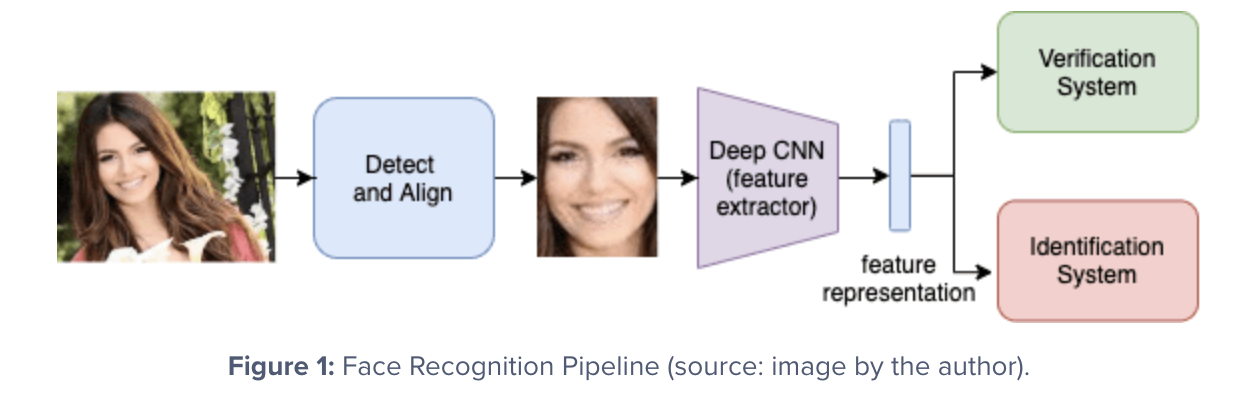

RECONOCIMIENTO FACIAL POR CLASIFICACIÓN (SE PARECE O NO)

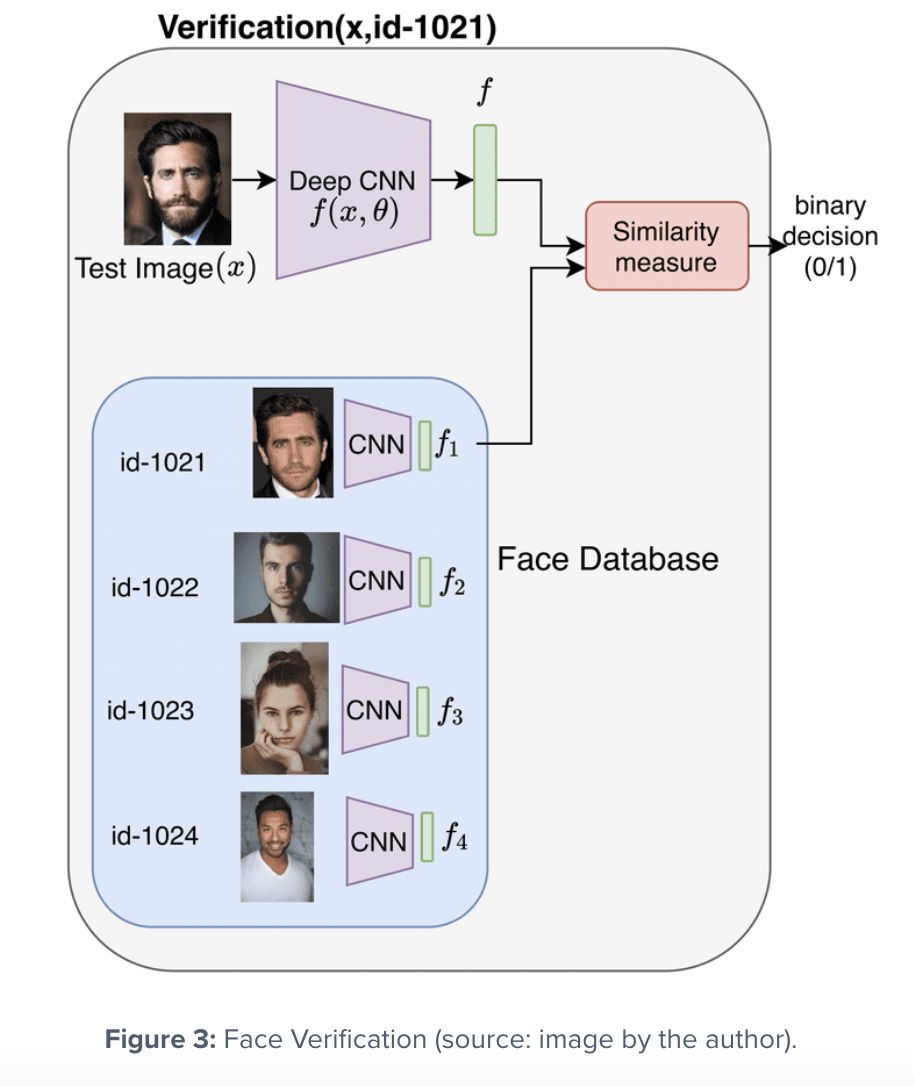

IDENTIFICACIÓN FACIAL POR VERIFICACIÓN (SIMILARIDAD)

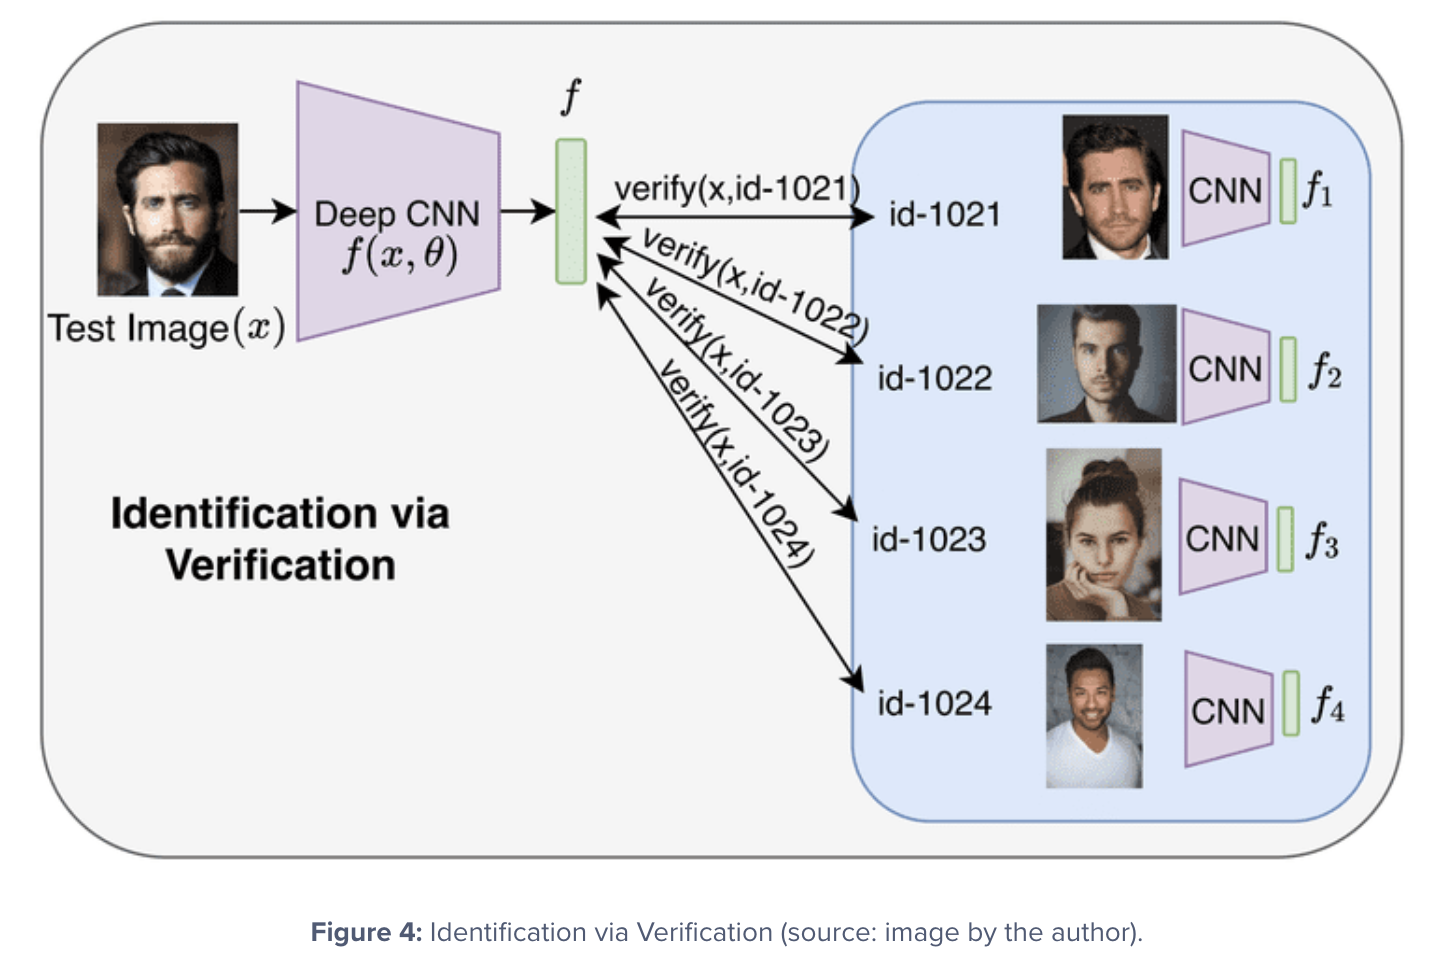

In [1]:
# IMPORTACIÓN DE LIBRERÍAS
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
from pathlib import Path
from keras import applications
from keras import layers
from keras import losses
from keras import ops
from keras import optimizers
from keras import metrics
from keras import Model
from keras.applications import resnet


target_shape = (200, 200)

# Cargar el conjunto de datos
Vamos a cargar el conjunto de datos "Totally Looks Like" (TTL) y descomprimirlo en el directorio ~/.keras del entorno local.

El conjunto de datos consta de dos archivos separados:

"left.zip" contiene las imágenes que usaremos como ancla (o imagen base) mientras que "right.zip" contiene las imágenes que usaremos como muestra positiva (una imagen que se parece al ancla).


In [ ]:
# ALGUNOS RECURSOS INTERESANTES
# https://es.shaip.com/blog/15-free-image-datasets-to-train-facial-recognition-models/
# https://www.kaggle.com/datasets/ruchi798/totally-looks-like-dataset
# https://medium.com/wicds/face-recognition-using-siamese-networks-84d6f2e54ea4
# https://github.com/neelanjan00/Face-Recognition-Facenet-
# https://github.com/adityajn105/Face-Recognition-Siamese-Network/
# https://www.packtpub.com/en-us/learning/how-to-tutorials/face-recognition-using-siamese-networks-tutorial/
# https://github.com/chen0040/keras-face
# https://machinelearningmastery.com/how-to-develop-a-face-recognition-system-using-facenet-in-keras-and-an-svm-classifier/
# https://medium.com/@issam.jebnouni/building-a-siamese-neural-network-for-face-verification-a-comprehensive-guide-562f997df309

In [2]:
cache_dir = Path(Path.home()) / ".keras"
anchor_images_path = cache_dir / "left"
positive_images_path = cache_dir / "right"

In [3]:
!gdown --id 1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34
!gdown --id 1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW
!unzip -oq left.zip -d $cache_dir
!unzip -oq right.zip -d $cache_dir

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34
From (redirected): https://drive.google.com/uc?id=1jvkbTr_giSP3Ru8OwGNCg6B4PvVbcO34&confirm=t&uuid=4217cd24-f6d0-4a9c-8545-2a20d8a6e46b
To: /content/left.zip
100% 104M/104M [00:00<00:00, 114MB/s] 
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW
From (redirected): https://drive.google.com/uc?id=1EzBZUb_mh_Dp_FKD0P4XiYYSd0QBH5zW&confirm=t&uuid=30b14785-777c-4c91-9de8-11e56a524b83
To: /content/right.zip
100% 104

# Preparación de los datos
Utilizaremos una pipeline de tf.data para cargar los datos y generar los tripletes necesarios para entrenar la red siamesa.
Configuraremos la canalización (pipeline) usando una lista comprimida con nombres de archivo de ancla, positivos y negativos como fuente. La canalización cargará y preprocesará las imágenes correspondientes.


In [4]:
def preprocess_image(filename):
    """
    Load the specified file as a JPEG image, preprocess it and
    resize it to the target shape.
    """

    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, target_shape)
    return image


def preprocess_triplets(anchor, positive, negative):
    """
    Given the filenames corresponding to the three images, load and
    preprocess them.
    """

    return (
        preprocess_image(anchor),
        preprocess_image(positive),
        preprocess_image(negative),
    )

Configuremos nuestra canalización (pipeline) de datos usando una lista comprimida con un nombre de archivo de imagen de ancla, positivo y negativo como origen. La salida de la canalización contiene el mismo triplete con cada imagen cargada y preprocesada.
Necesitamos asegurarnos de que tanto las imágenes de anclaje como las positivas estén cargadas en orden para que podamos combinarlas.

In [5]:
anchor_images = sorted(
    [str(anchor_images_path / f) for f in os.listdir(anchor_images_path)]
)

positive_images = sorted(
    [str(positive_images_path / f) for f in os.listdir(positive_images_path)]
)

image_count = len(anchor_images)

anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_images)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_images)

# To generate the list of negative images, let's randomize the list of
# available images and concatenate them together.
rng = np.random.RandomState(seed=42)
rng.shuffle(anchor_images)
rng.shuffle(positive_images)

negative_images = anchor_images + positive_images
np.random.RandomState(seed=32).shuffle(negative_images)

negative_dataset = tf.data.Dataset.from_tensor_slices(negative_images)
negative_dataset = negative_dataset.shuffle(buffer_size=4096)

dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))
dataset = dataset.shuffle(buffer_size=1024)
dataset = dataset.map(preprocess_triplets)

# Let's now split our dataset in train and validation.
train_dataset = dataset.take(round(image_count * 0.8))
val_dataset = dataset.skip(round(image_count * 0.8))

train_dataset = train_dataset.batch(32, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(32, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

Veamos algunos ejemplos de tripletes. Observe cómo las dos primeras imágenes se parecen, mientras que la tercera siempre es diferente.

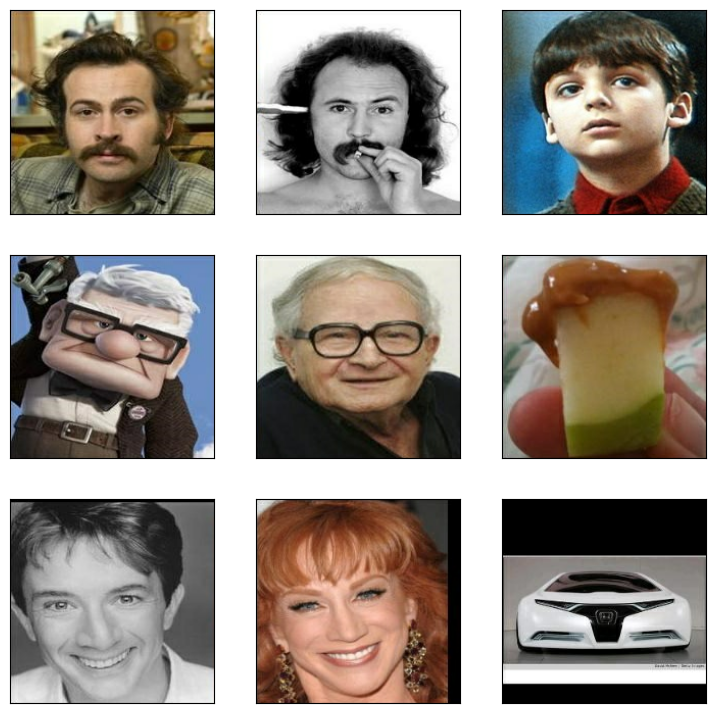

In [6]:
def visualize(anchor, positive, negative):
    """Visualize a few triplets from the supplied batches."""

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))

    axs = fig.subplots(3, 3)
    for i in range(3):
        show(axs[i, 0], anchor[i])
        show(axs[i, 1], positive[i])
        show(axs[i, 2], negative[i])


visualize(*list(train_dataset.take(1).as_numpy_iterator())[0])

# Configuración del modelo generador de incrustaciones (embeddings)
Nuestra red siamesa generará incrustaciones para cada imagen del triplete. Para ello, utilizaremos un modelo ResNet50 preentrenado en ImageNet y le conectaremos algunas capas densas para aprender a separar estas incrustaciones.

Congelaremos los pesos de todas las capas del modelo hasta la capa conv5_block1_out. Esto es importante para evitar que se afecten los pesos que el modelo ya ha aprendido. Dejaremos las capas inferiores entrenables para poder ajustar sus pesos durante el entrenamiento.

In [7]:
base_cnn = resnet.ResNet50(
    weights="imagenet", input_shape=target_shape + (3,), include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Configuración del modelo de red siamesa
La red siamesa recibirá cada una de las imágenes triplete como entrada, generará las incrustaciones y generará la distancia entre el ancla y la incrustación positiva, así como la distancia entre el ancla y la incrustación negativa.

Para calcular la distancia, podemos usar una capa personalizada, DistanceLayer, que devuelve ambos valores como una tupla.

In [8]:
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = ops.sum(tf.square(anchor - positive), -1)
        an_distance = ops.sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=target_shape + (3,))
positive_input = layers.Input(name="positive", shape=target_shape + (3,))
negative_input = layers.Input(name="negative", shape=target_shape + (3,))

distances = DistanceLayer()(
    embedding(resnet.preprocess_input(anchor_input)),
    embedding(resnet.preprocess_input(positive_input)),
    embedding(resnet.preprocess_input(negative_input)),
)

siamese_network = Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

# Juntando todo
Ahora necesitamos implementar un modelo con un bucle de entrenamiento personalizado para calcular la pérdida de tripletes utilizando las tres incrustaciones producidas por la red siamesa.

Creemos una instancia de métrica media para rastrear la pérdida del proceso de entrenamiento.

In [9]:
class SiameseModel(Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]

# Entrenamiento
Ahora estamos listos para entrenar nuestro modelo.

In [10]:
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(optimizer=optimizers.Adam(0.0001))
siamese_model.fit(train_dataset, epochs=10, validation_data=val_dataset)

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 66s 221ms/step - loss: 0.6493 - val_loss: 0.3920
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.3907 - val_loss: 0.3584
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.3656 - val_loss: 0.3631
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.3392 - val_loss: 0.3414
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.3256 - val_loss: 0.3394
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.3095 - val_loss: 0.3222
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.2992 - val_loss: 0.3300
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.2920 - val_loss: 0.3347
Epoch 9/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.2832 - val_loss: 0.3007
Epoch 10/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.2776 - val_loss: 0.3221


# Inspeccionando lo que la red ha aprendido
En este punto, podemos comprobar cómo la red aprendió a separar las incrustaciones según pertenezcan a imágenes similares.

Podemos utilizar la similitud de coseno para medir la similitud entre incrustaciones.

Tomemos una muestra del conjunto de datos para comprobar la similitud entre las incrustaciones generadas para cada imagen.

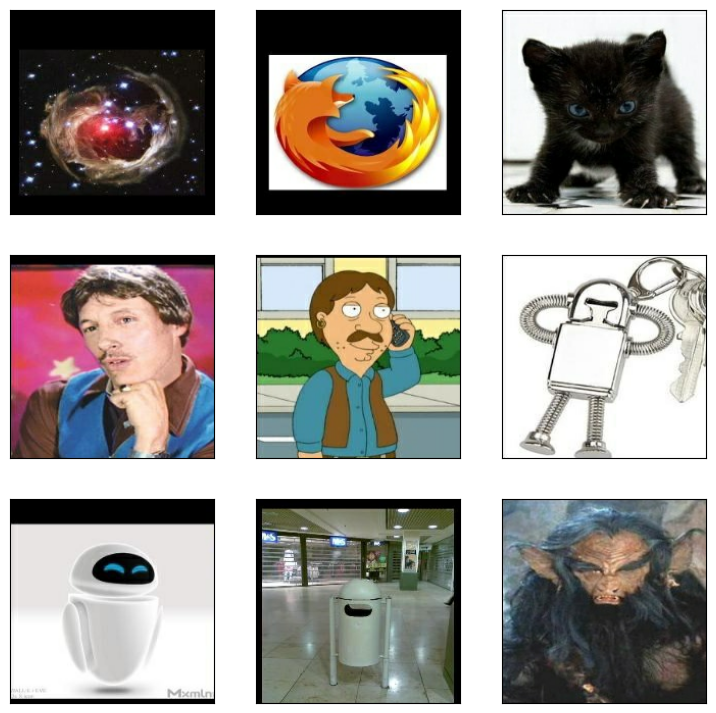

In [11]:
sample = next(iter(train_dataset))
visualize(*sample)

anchor, positive, negative = sample
anchor_embedding, positive_embedding, negative_embedding = (
    embedding(resnet.preprocess_input(anchor)),
    embedding(resnet.preprocess_input(positive)),
    embedding(resnet.preprocess_input(negative)),
)

Finalmente, podemos calcular la similitud del coseno entre las imágenes de ancla y positiva y compararla con la similitud entre las imágenes de ancla y negativa.

Deberíamos esperar que la similitud entre las imágenes de ancla y positiva sea mayor que la similitud entre las imágenes de ancla y negativa.

In [12]:
cosine_similarity = metrics.CosineSimilarity()

positive_similarity = cosine_similarity(anchor_embedding, positive_embedding)
print("Positive similarity:", positive_similarity.numpy())

negative_similarity = cosine_similarity(anchor_embedding, negative_embedding)
print("Negative similarity", negative_similarity.numpy())

Positive similarity: 0.98897624
Negative similarity 0.9852635


# Resumen
La API tf.data permite crear pipelines de entrada eficientes para el modelo. Resulta especialmente útil si se dispone de un conjunto de datos grande. Puede obtener más información sobre los pipelines de tf.data en tf.data: Crear pipelines de entrada de TensorFlow.

En este ejemplo, utilizamos una ResNet50 preentrenada como parte de la subred que genera las incrustaciones de características. Mediante el aprendizaje por transferencia, podemos reducir significativamente el tiempo de entrenamiento y el tamaño del conjunto de datos.

Observe cómo estamos ajustando los pesos de las capas finales de la red ResNet50, manteniendo el resto de las capas intactas. Usando el nombre asignado a cada capa, podemos congelar los pesos a un valor determinado y mantener abiertas las últimas capas.

Podemos crear capas personalizadas creando una clase que herede de tf.keras.layers.Layer, como hicimos en la clase DistanceLayer.

Utilizamos una métrica de similitud de coseno para medir la similitud entre dos incrustaciones de salida.

Puede implementar un bucle de entrenamiento personalizado sobrescribiendo el método train_step(). train_step() utiliza tf.GradientTape, que registra cada operación que se realiza dentro de él. En este ejemplo, lo usamos para acceder a los gradientes pasados ​​al optimizador y actualizar los pesos del modelo en cada paso. Para más detalles, consulte Introducción a Keras para investigadores y Escritura de un bucle de entrenamiento desde cero.